Saving telco_customer_churn.csv to telco_customer_churn.csv
Column datatypes:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object



Checking column: customerID
Sample values:
0    7590-VHVEG
1    5575-GNVDE
2    3668-QPYBK
3    7795-CFOCW
4    9237-HQITU
Name: customerID, dtype: object
Unique values: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

Checking column: gender
Sample values:
0    Female
1      Mal

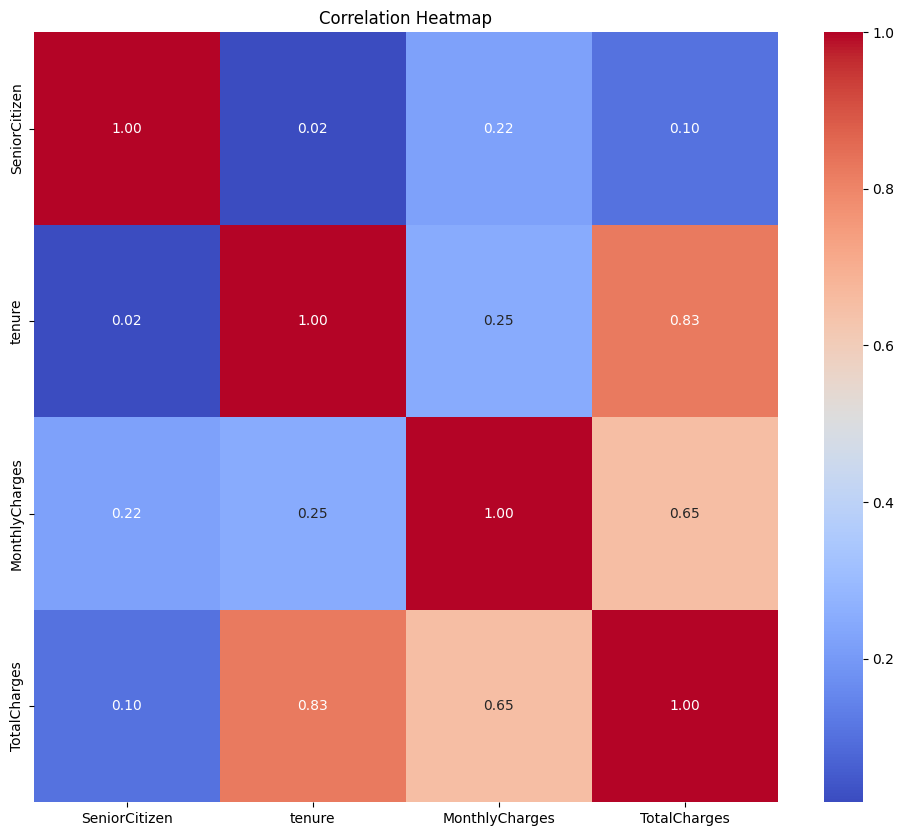

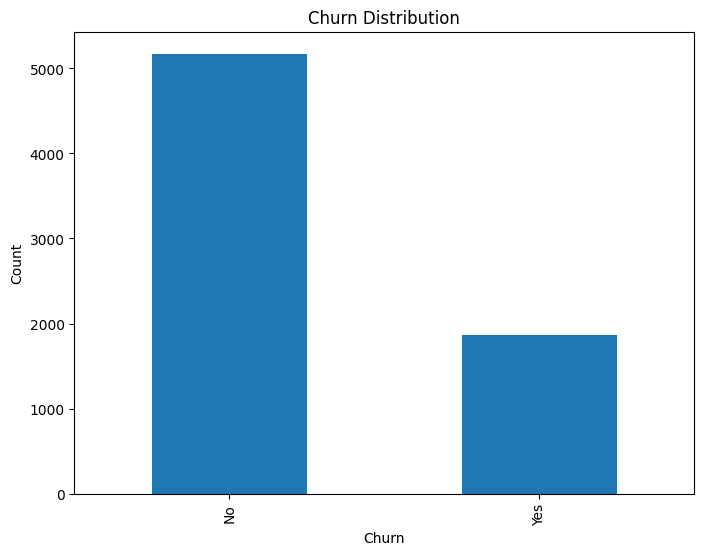

check missing values
TotalCharges:
  - Null values: 11
  - Empty strings: 0
  - Whitespace only: 0

Preprocessing Data...

Splitting Dataset...

Training and Evaluating Models...


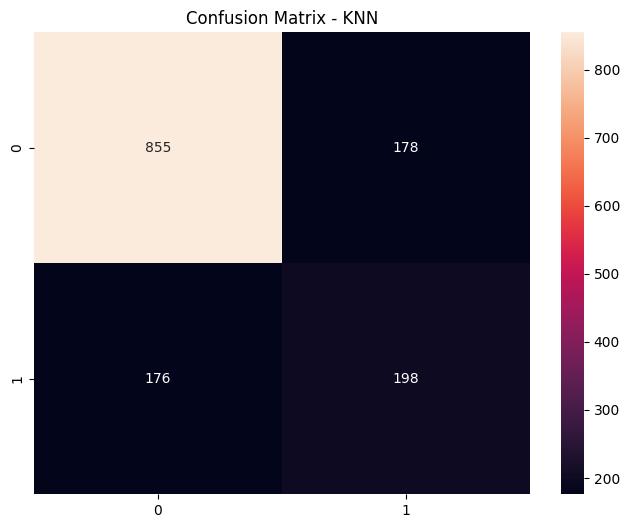

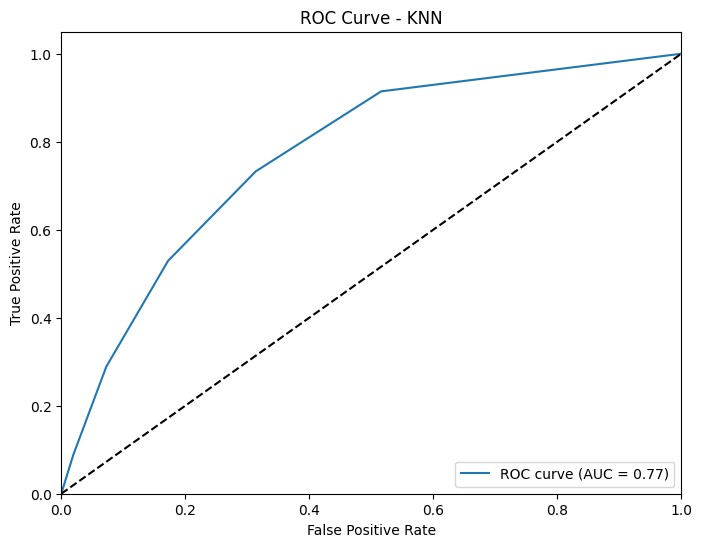

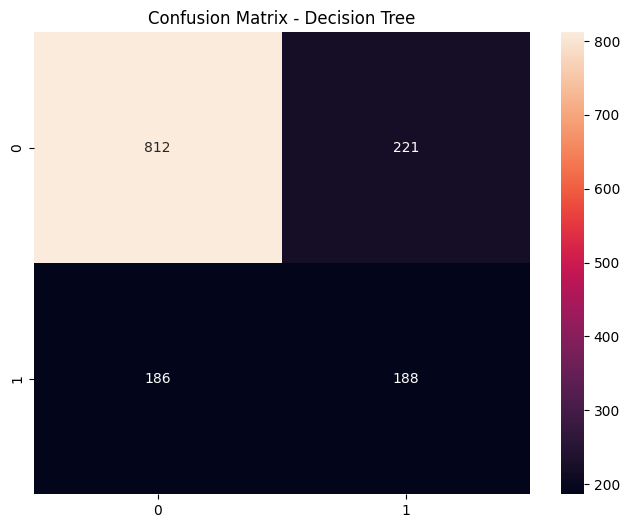

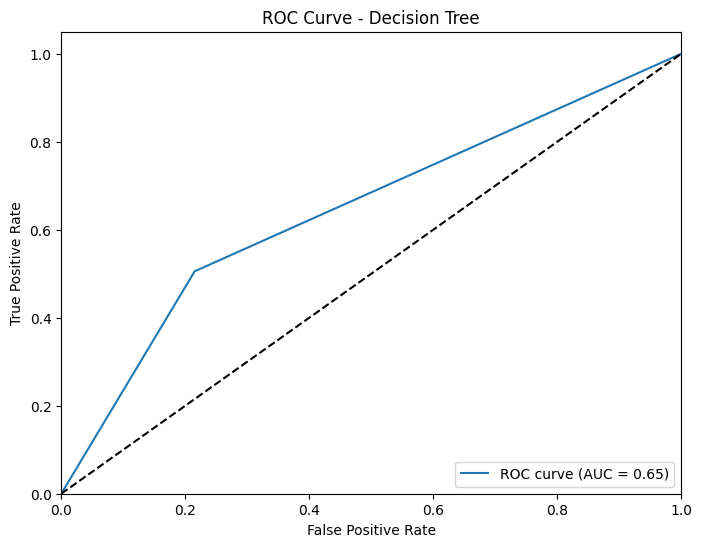

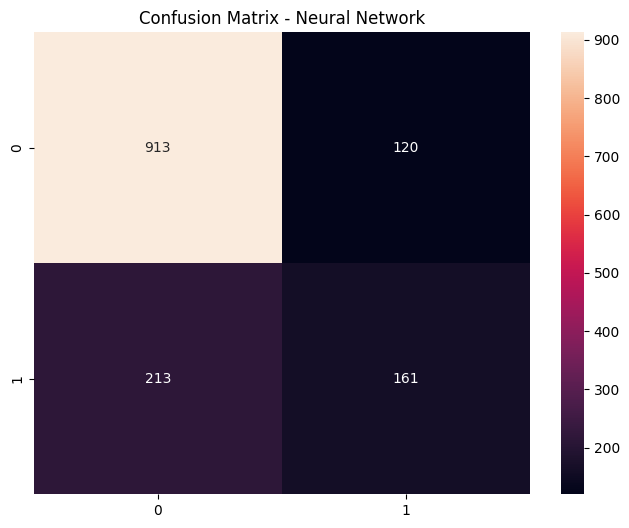

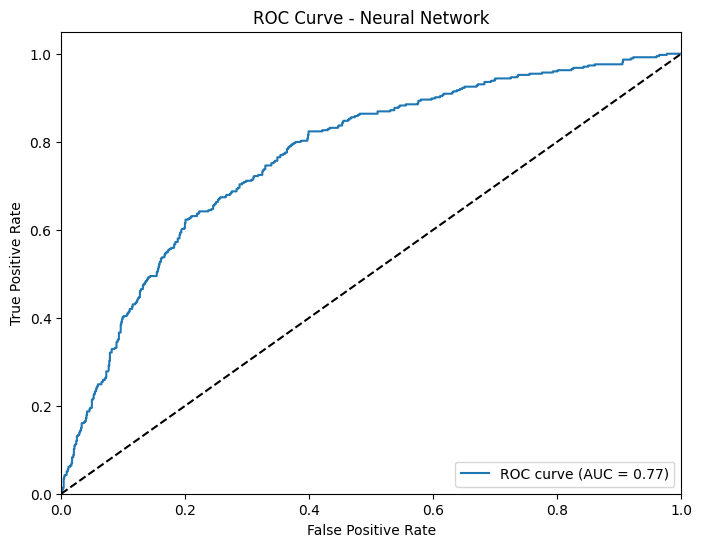


Model Performance Results:

KNN:
Accuracy: 0.7484
Precision: 0.7488
Recall: 0.7484
F1-Score: 0.7486
ROC-AUC: 0.7708


Decision Tree:
Accuracy: 0.7107
Precision: 0.7195
Recall: 0.7107
F1-Score: 0.7147
ROC-AUC: 0.6452


Neural Network:
Accuracy: 0.7633
Precision: 0.7476
Recall: 0.7633
F1-Score: 0.7516
ROC-AUC: 0.7687


Applying K-means Clustering...


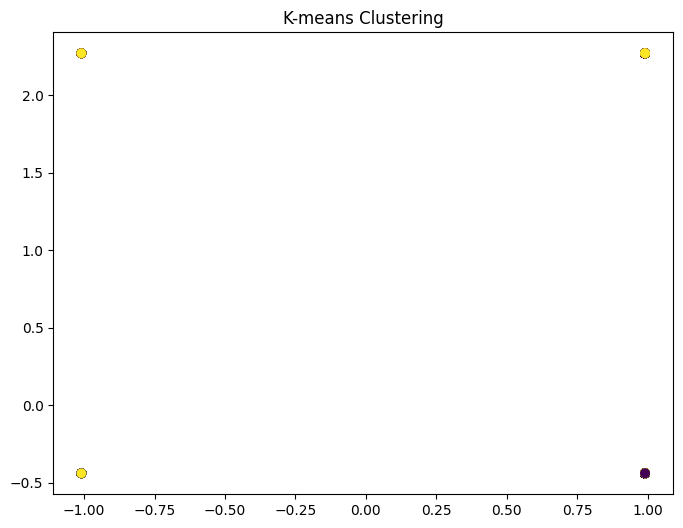

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, auc
import warnings
warnings.filterwarnings('ignore')



# Dataset Description
def analyze_dataset(df):
    print("Dataset Shape:", df.shape)
    print("\nFeature Types:")
    print(df.dtypes)
    print("\nMissing Values:")
    print(df.isnull().sum())

    # Remove 'customerID' for correlation analysis
    df_corr = df.drop(['customerID'], axis=1)
    # Convert 'TotalCharges' to numeric
    df_corr['TotalCharges'] = pd.to_numeric(df_corr['TotalCharges'], errors='coerce')

    # Correlation Matrix
    plt.figure(figsize=(12, 10))
    numeric_df = df_corr.select_dtypes(include=['float64', 'int64'])
    sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap')
    plt.show()

    # Class Distribution
    plt.figure(figsize=(8, 6))
    df['Churn'].value_counts().plot(kind='bar')
    plt.title('Churn Distribution')
    plt.xlabel('Churn')
    plt.ylabel('Count')
    plt.show()

# Data Preprocessing
def preprocess_data(df):
    # Remove customerID
    df = df.drop(['customerID'], axis=1)

    # Convert TotalCharges to numeric
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

    # Handle missing values
    df = df.dropna()

    # Encode categorical variables
    le = LabelEncoder()
    categorical_cols = df.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        df[col] = le.fit_transform(df[col])

    # Separate features and target
    X = df.drop('Churn', axis=1)
    y = df['Churn']

    # Feature scaling
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

    return X_scaled, y

# Dataset Splitting
def split_dataset(X, y):
    return train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Model Training and Testing
def train_and_evaluate_models(X_train, X_test, y_train, y_test):
    models = {
        'KNN': KNeighborsClassifier(n_neighbors=5),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'Neural Network': MLPClassifier(hidden_layer_sizes=(100, 50),
                                      max_iter=1000,
                                      random_state=42)
    }


    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Check if predict_proba exists (some models might not)
        if hasattr(model, "predict_proba"):
            y_pred_proba = model.predict_proba(X_test)[:, 1]
        else:
            y_pred_proba = None

        # Metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_test, y_pred, average='weighted'
        )
        roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None

        results[name] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,   # use computed value directly
            'roc_auc': roc_auc
        }

        # Confusion Matrix
        plt.figure(figsize=(8, 6))
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d')
        plt.title(f'Confusion Matrix - {name}')
        plt.show()

        # ROC Curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - {name}')
        plt.legend(loc="lower right")
        plt.show()

    return results

# Unsupervised Learning
def apply_kmeans(X):
    kmeans = KMeans(n_clusters=3, random_state=42)  # Here we can adjust number of clusters as needed (using a simple value = 3 at first)
    clusters = kmeans.fit_predict(X)

    # Visualize clusters (using first two features)
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=clusters)
    plt.title('K-means Clustering')
    plt.show()

#Method fpr checking missing values
def check_missing(df):
    for column in df.columns:
        # Check different types of missing values
        null_count = df[column].isnull().sum()
        empty_count = (df[column] == '').sum() if df[column].dtype == 'object' else 0
        space_count = df[column].astype(str).str.isspace().sum()

        if null_count > 0 or empty_count > 0 or space_count > 0:
            print(f"{column}:")
            print(f"  - Null values: {null_count}")
            print(f"  - Empty strings: {empty_count}")
            print(f"  - Whitespace only: {space_count}")



# Function call
def main():
    # Load the dataset
    from google.colab import files
    uploaded = files.upload()
    df = pd.read_csv('telco_customer_churn.csv')

   # First, let's check all columns' dtypes
    print("Column datatypes:")
    print(df.dtypes)
    print("\n")

   # Function to check for leading/trailing whitespace
    def check_whitespace(df, column):
      has_leading = df[df[column].str.strip() != df[column]].shape[0]
      if has_leading > 0:
        print(f"Column '{column}' has {has_leading} rows with leading/trailing whitespace")
        #replace with nan
        print((df[f'{column}'].str.isspace()).sum())
        df[f'{column}'] = df[f'{column}'].replace(' ', pd.NA)
        print("\nMissing values after replacing whitespace with NaN:")
        print(df[f'{column}'].isna().sum())

   # Check all object/string columns and any numeric columns stored as strings
    for column in df.columns:
      if df[column].dtype == 'object':  # Check string/object columns
         print(f"\nChecking column: {column}")
         print(f"Sample values:\n{df[column].head()}")
         check_whitespace(df, column)
         print("Unique values:", df[column].unique())

    # Additional check for numeric columns that might be stored as strings
      elif df[column].dtype != 'object':
        string_values = df[column].astype(str)
        if (string_values.str.strip() != string_values).any():
            print(f"\nPotential whitespace issues in numeric column: {column}")
            print("Sample values:", df[column].head())


    # Analyze the dataset
    print("Dataset Analysis:")
    analyze_dataset(df)

    #check missing values
    print("check missing values")
    check_missing(df)

    # Preprocess the data
    print("\nPreprocessing Data...")
    X_scaled, y = preprocess_data(df)

    # Split the dataset
    print("\nSplitting Dataset...")
    X_train, X_test, y_train, y_test = split_dataset(X_scaled, y)

    # Train and evaluate models
    print("\nTraining and Evaluating Models...")
    results = train_and_evaluate_models(X_train, X_test, y_train, y_test)

    # Print results
    print("\nModel Performance Results:")
    for model_name, metrics in results.items():
        print(f"\n{model_name}:")
        print(f"Accuracy: {metrics['accuracy']:.4f}")
        print(f"Precision: {metrics['precision']:.4f}")
        print(f"Recall: {metrics['recall']:.4f}")
        print(f"F1-Score: {metrics['f1_score']:.4f}")
        if metrics['roc_auc'] is not None:
           print(f"ROC-AUC: {metrics['roc_auc']:.4f}")
        print()


    # Apply K-means clustering
    print("\nApplying K-means Clustering...")
    apply_kmeans(X_scaled.values)

if __name__ == "__main__":
    main()

